### Explainability - DEEP SYNERGY

In total, we implemented:

-  SHAP -- Michael.F
-  Feature Ablation -- Michael F.
-  Integrated Gradients -- Zhao
-  Permutation Importence -- Zhao
-  Partial dependence Plot (PDP) -- Zhao -- but doesn't make much sense

(you can find all codes in our repository in Github)



### Integrated Gradients





In [ ]:
import os
import torch
import gzip
import pickle
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

# =============================================================================
# 1. configuration
# =============================================================================
MODEL_PATH = "test0val1normtanh_norm.p_model.pt"  
DATA_PATH  = "test0val1normtanh_norm.p.gz"         
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
N_STEPS    = 50     
BATCH_SIZE = 64   

In [ ]:
# =============================================================================
# 2. Load data once to get input dimension D
# =============================================================================
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")
with gzip.open(DATA_PATH, "rb") as f:
    X_tr, X_val, X_train, X_test, y_tr, y_val, y_train, y_test = pickle.load(f)
D = X_test.shape[1]
print(f"✔ Data loaded: test set has {X_test.shape[0]} samples, input dimension D={D}")

# =============================================================================
# 3. Load model
# =============================================================================
raw = torch.load(MODEL_PATH, map_location=DEVICE)
if isinstance(raw, torch.nn.Module):
    model = raw.to(DEVICE)
    print("✔ Loaded full model object")
elif isinstance(raw, dict):
    from model import Encoder, LitAutoEncoder  # adjust import as needed
    encoder = Encoder(
        input_size=D,
        layers=[8192, 4096, 1],  # match training config
        input_dropout=0.2,
        hidden_dropout=0.5
    )
    model = LitAutoEncoder(encoder=encoder, learning_rate=1e-4).to(DEVICE)
    # Add "encoder." prefix if missing
    if not next(iter(raw)).startswith("encoder."):
        raw = {"encoder." + k: v for k, v in raw.items()}
    missing, unexpected = model.load_state_dict(raw, strict=False)
    if missing:
        print("⚠ Missing keys:", missing)
    if unexpected:
        print("⚠ Unexpected keys:", unexpected)
    print("✔ Loaded state_dict into model")
else:
    raise RuntimeError(f"Unsupported model format: {type(raw)}")
model.eval()
print(f"✔ Model moved to {DEVICE}")

# =============================================================================
# 4. Prepare test tensor and zero baseline
# =============================================================================
X_test = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)  # shape [N, D]
baseline_template = torch.zeros(1, D, device=DEVICE)               # shape [1, D]

# =============================================================================
# 5. Define forward function for IG to ensure output shape [batch, 1]
# =============================================================================
def forward_for_ig(x: torch.Tensor) -> torch.Tensor:
    out = model(x)
    if out.dim() == 0:
        return out.unsqueeze(0).unsqueeze(1)
    if out.dim() == 1:
        return out.unsqueeze(1)
    return out

# Quick check of forward_for_ig
_dummy = torch.randn(2, D, device=DEVICE)
assert forward_for_ig(_dummy).shape == (2, 1)

# =============================================================================
# 6. Compute Integrated Gradients in batches
# =============================================================================
ig = IntegratedGradients(forward_for_ig)
all_attrs = []

print(f"\n▶ Computing IG in batches (n_steps={N_STEPS}, batch_size={BATCH_SIZE})...")
for i in range(0, len(X_test), BATCH_SIZE):
    xb = X_test[i : i + BATCH_SIZE]                    # shape [b, D]
    baseline = baseline_template.expand(xb.size(0), D)  # shape [b, D]
    attr = ig.attribute(
        inputs=xb,
        baselines=baseline,
        target=0,
        n_steps=N_STEPS,
        return_convergence_delta=False
    )
    all_attrs.append(attr.detach().cpu().numpy())
    done = min(i + BATCH_SIZE, len(X_test))
    print(f"  • Completed {done}/{len(X_test)}")

all_attrs = np.vstack(all_attrs)  # shape (N_test, D)
print("✔ IG computation finished; attribution matrix shape =", all_attrs.shape)

# =============================================================================
# 7. Aggregate and visualize: Top-20 bar chart, dot plot, module pie chart, heatmap
# =============================================================================
mean_abs_attr = np.mean(np.abs(all_attrs), axis=0)  # global average attribution

# ----- Top-20 average |IG| bar chart -----
K = 20
idx20 = np.argsort(mean_abs_attr)[-K:]
vals20 = mean_abs_attr[idx20]

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(range(K), vals20, color="skyblue")
ax.set_yticks(range(K))
ax.set_yticklabels([f"Feat {i}" for i in idx20], fontsize=10)
ax.set_xlabel("Mean |IG Attribution|")
ax.set_title("DeepSynergy IG Mean Top-20 Features")
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
plt.tight_layout()
plt.savefig("fast_ig_top20_mean_100.png", dpi=200)
plt.close()

# ----- x Dot plot of Top-20 average |IG| -----
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(vals20, range(K), s=50, color="steelblue")
ax.set_yticks(range(K))
ax.set_yticklabels([f"Feat {i}" for i in idx20], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Mean |IG Attribution|")
ax.set_title("DeepSynergy IG Mean Top-20 Features (Dot Plot)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ig_dotplot_top20_100.png", dpi=200)
plt.close()

# -----  Module-level pie chart (Drug A / Drug B / Cell Expr) -----
dA, dB = 614, 614  # fingerprint sizes
sums = [
    mean_abs_attr[:dA].sum(),
    mean_abs_attr[dA : dA + dB].sum(),
    mean_abs_attr[dA + dB :].sum()
]
labels = ["Drug A", "Drug B", "Cell Expr"]
colors = ["#8dd3c7", "#ffffb3", "#bebada"]

fig, ax = plt.subplots(figsize=(4, 4))
wedges, texts, autotexts = ax.pie(
    sums, labels=labels, autopct="%.1f%%", startangle=90,
    colors=colors, textprops={"bbox": {"facecolor":"none","edgecolor":"none"}}
)
for t in autotexts: t.set_bbox({"facecolor":"none","edgecolor":"none"})
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_title("IG Module Proportions (mean)", bbox={"facecolor":"none","edgecolor":"none"})
plt.tight_layout()
plt.savefig("ig_pie_mean.png", dpi=200)
plt.close()

print("\n All visualizations saved:")
print("  • fast_ig_top20_mean.png")
print("  • ig_dotplot_top20.png")
print("  • ig_pie_mean.png")

## Visulizations:

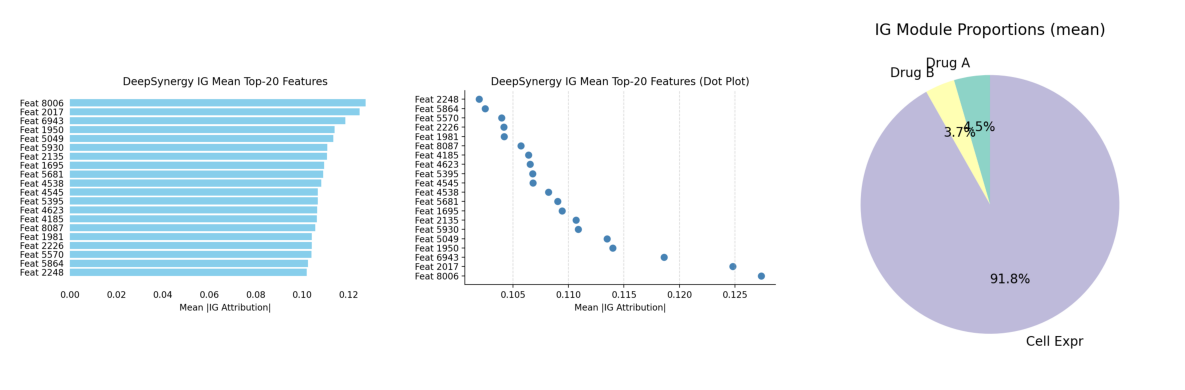

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

bild1 = '/Users/guoguo/Desktop/Studium/6.Semester/SWP/ig_top20_mean.png'
bild2 = '/Users/guoguo/Desktop/Studium/6.Semester/SWP/ig_dotplot_top20.png'
bild3 = '/Users/guoguo/Desktop/Studium/6.Semester/SWP/ig_pie_mean.png'

fig, axes = plt.subplots(1, 3, figsize=(12, 4))# one row, three columns
for ax, fname in zip(axes, [bild1, bild2, bild3]):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Conclusion for IG - result :**

**Module‐level attribution (pie chart)**

The pie chart shows how the Integrated Gradients attributions distribute across the three data modalities. 

- Cell Expression: ~92% of the total IG magnitude

- Drug A fingerprint: ~4–5%

- Drug B fingerprint: ~3–4%

this tells us that the model is relying overwhelmingly on **cell‐line gene expression** features, with the chemical fingerprints of the two drugs contributing only a small fraction of the attribution.

**Global Top-20 features (bar chart)**

The bar chart lists the 20 individual input dimensions (i.e. specific genes or fingerprint bits) whose average absolute attributions are highest. All of these top-20 indices fall well into the cell‐expression region(since drug features occupy only the first 1,228 dims), confirming again that the model’s strongest “drivers” are individual gene expression values.

**Global Top-20 features (dot plot)**

The dot plot shows the same Top-20 features as the bar chart but as individual points, which can make it easier to see relative differences. The downward ordering emphasizes that “Feat 8006” is the single most influential dimension on average, followed by “Feat 2017,” and so on.

### Permutation importance

In [ ]:
import os
import sys
import gzip
import pickle
import traceback

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base import BaseEstimator, RegressorMixin

# ———— Configuration ———— #
CONFIG = {
    "MODEL_FILE": "test0val1normtanh_norm.p_model.pt",  # Path to the trained model file
    "DATA_FILE":  "test0val1normtanh_norm.p.gz",        # Path to the gzipped data file
    "OUTDIR":     "Permutation_pdp",                    # Directory for output plots

    "VAR_TOPK":  50,    # Number of top-variance features to select
    "PERM_TOPK": 20,    # Number of top features by permutation importance to plot
    "PDP_TOPK":  3,     # Number of top features for PDP
    "PDP_GRID":  10,    # Number of grid points for PDP calculation

    "FIGSIZE_PERM": (8, 6),  # Figure size for permutation importance plot
    "FIGSIZE_PDP":  (8, 5),  # Figure size for PDP plot
    "FONT_SIZE":    12,      # Font size for plot labels
}
# ———————————————————————— #


class TorchRegressor(BaseEstimator, RegressorMixin):
    """
    Adapter to wrap a PyTorch model as a scikit-learn regressor.
    """
    _estimator_type = "regressor"

    def __init__(self, model, device="cpu"):
        self.model = model.to(device)
        self.device = device

    def fit(self, X, y=None):
        """
        Fake fit: record number of features and set necessary attributes for sklearn compatibility.
        """
        X = np.asarray(X)
        # 1) Number of input features
        self.n_features_in_ = X.shape[1]
        # 2) Provide feature names (using indices here)
        self.feature_names_in_ = np.arange(X.shape[1])
        # 3) Mark as fitted
        self.is_fitted_ = True
        return self

    def predict(self, X):
        """
        Run the model in evaluation mode and return predictions as a 1D numpy array.
        """
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32, device=self.device)
            out = self.model(t).cpu().numpy().ravel()
        return out



def load_model(path, input_dim, device):
    """
    Load a PyTorch model from file. Supports both full nn.Module and state_dict formats.
    """
    print(f"[DEBUG] Loading model from {path} on {device}")
    raw = torch.load(path, map_location=device)

    if isinstance(raw, torch.nn.Module):
        mdl = raw.to(device)
    elif isinstance(raw, dict):
        from dnn import DeepSynergyNet
        # Reconstruct model architecture
        mdl = DeepSynergyNet(input_size=input_dim).to(device)
        # If keys lack encoder prefix, add it
        if not next(iter(raw)).startswith("encoder."):
            raw = {f"encoder.{k}": v for k, v in raw.items()}
        mdl.load_state_dict(raw, strict=False)
    else:
        raise RuntimeError(f"Unsupported model format: {type(raw)}")

    print("✔ Model loaded and set to eval mode")
    return mdl.eval()



def main():
    print(f"[DEBUG] Executing script at: {os.path.abspath(__file__)}")
    try:
        # 1. Check model and data files exist
        for key in ("MODEL_FILE", "DATA_FILE"):
            path = CONFIG[key]
            if not os.path.isfile(path):
                print(f"✖ File not found: {path}")
                sys.exit(1)
            else:
                print(f"✔ Found file: {path}")

        # 2. Prepare output directory
        outdir = CONFIG["OUTDIR"]
        os.makedirs(outdir, exist_ok=True)
        print(f"✔ Output directory ready: {outdir}")

        # 3. Load data
        print("[DEBUG] Loading data...")
        with gzip.open(CONFIG["DATA_FILE"], "rb") as f:
            X_tr, X_val, X_train, X_test, y_tr, y_val, y_train, y_test = pickle.load(f)
        X_test_np = np.array(X_test, dtype=np.float32)
        y_test_np = np.array(y_test, dtype=np.float32)
        n, D = X_test_np.shape
        print(f"✔ Loaded test data: {n} samples, {D} features")

        # 4. Load and wrap model
        device = "cuda" if torch.cuda.is_available() else "cpu"
        model = load_model(CONFIG["MODEL_FILE"], D, device)
        reg = TorchRegressor(model, device=device)
        reg.fit(X_test_np, y_test_np)
        print("✔ TorchRegressor fitted for PDP")

        # 5. Compute baseline MSE
        print("[DEBUG] Computing baseline MSE...")
        y_base = reg.predict(X_test_np)
        mse_base = mean_squared_error(y_test_np, y_base)
        print(f"✔ Baseline MSE = {mse_base:.4f}")

        # 6. Select features by variance
        print("[DEBUG] Selecting top variance features...")
        var = X_test_np.var(axis=0)
        var_idxs = np.argsort(var)[-CONFIG["VAR_TOPK"]:]
        print(f"✔ Selected top-{CONFIG['VAR_TOPK']} variance features")

        # 7. Compute permutation importances
        print("[DEBUG] Calculating permutation importances...")
        perm_imp = []
        for j in var_idxs:
            Xp = X_test_np.copy()
            np.random.shuffle(Xp[:, j])
            y_p = reg.predict(Xp)
            delta = mean_squared_error(y_test_np, y_p) - mse_base
            perm_imp.append(delta)
            print(f"[DEBUG] Feat {j}: ΔMSE={delta:.4f}")
        perm_imp = np.array(perm_imp)

        # 8. Plot permutation importances
        print("[DEBUG] Plotting permutation importances...")
        topk = CONFIG["PERM_TOPK"]
        idx_top = np.argsort(perm_imp)[-topk:]
        fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_PERM"])
        ax.barh(range(topk), perm_imp[idx_top], color="skyblue")
        ax.set_yticks(range(topk))
        ax.set_yticklabels([f"Feat {var_idxs[i]}" for i in idx_top], fontsize=CONFIG["FONT_SIZE"])
        ax.set_xlabel("ΔMSE after permutation", fontsize=CONFIG["FONT_SIZE"])
        ax.set_title(f"Top-{topk} Permutation Importances", fontsize=CONFIG["FONT_SIZE"] + 2)
        ax.tick_params(left=False, bottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)
        out1 = os.path.join(outdir, f"perm_imp_top{topk}.png")
        plt.tight_layout()
        plt.savefig(out1, dpi=200)
        plt.close()
        print(f"✔ Saved permutation importance plot to {out1}")

    except Exception:
        print("✖ An error occurred:")
        traceback.print_exc()


if __name__ == "__main__":
    main()

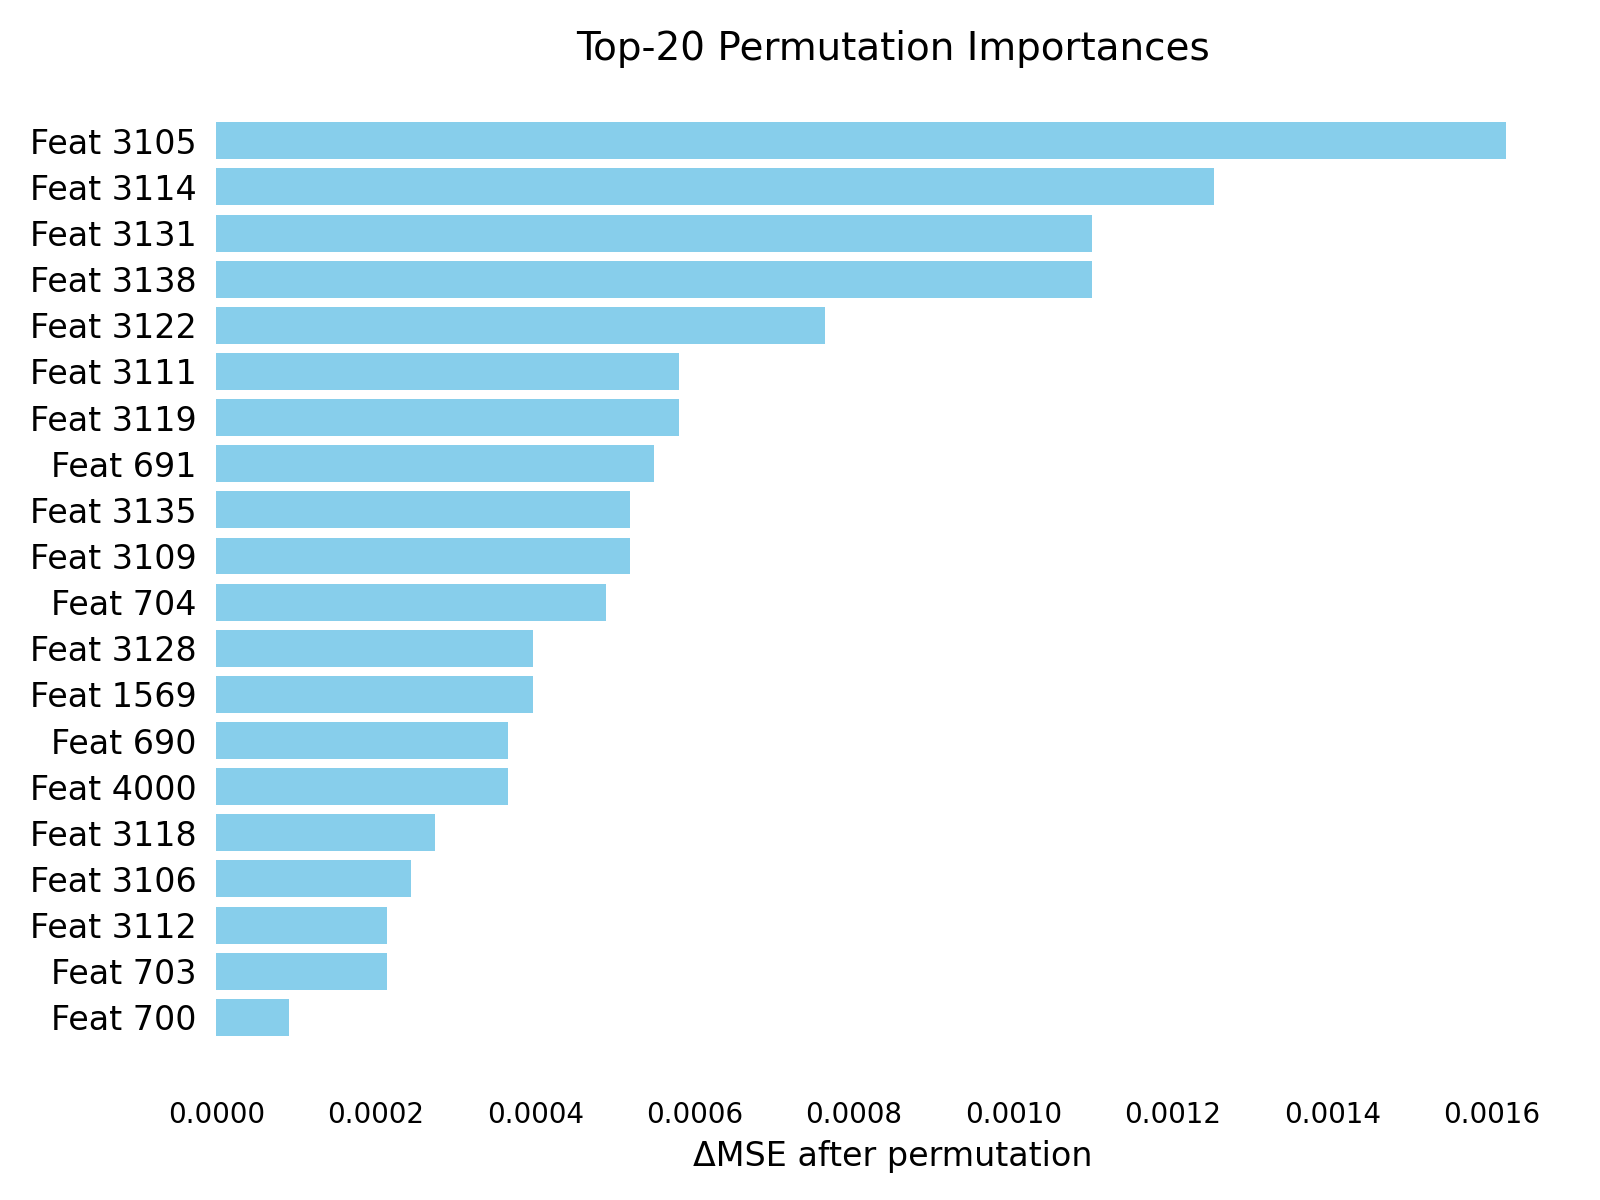

In [13]:
from IPython.display import Image, display

img = Image(filename='/Users/guoguo/Desktop/Studium/6.Semester/SWP/perm_imp_top20.png', width=500, height=450)
display(img)

This plot shows the Top-20 feature importances as measured by permutation importance on our model:

- Y-axis ：These are the feature names from dataset, sorted from most to least important.

- X-axis ：For each feature, you randomly shuffle (permute) its values across validation set and measure how much the model’s Mean Squared Error (MSE) increases. 

- A larger ΔMSE means the model relied heavily on that feature.

- A smaller ΔMSE means the feature had little impact on model accuracy.



In [ ]:
import os
import gzip
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

# If you are using LightningModule, import it:
from model import Encoder, LitAutoEncoder  # Adjust according to your project structure

# —————————————————————————————————————
# 1. Configuration: model path, data path, output file
# —————————————————————————————————————
MODEL_FILE = "test0val1normtanh_norm.p_model.pt"
DATA_FILE  = "test0val1normtanh_norm.p.gz"
OUT_FILE   = "pdp_top3.png"

# —————————————————————————————————————
# 2. Load test data
# —————————————————————————————————————
with gzip.open(DATA_FILE, "rb") as f:
    X_tr, X_val, X_train, X_test, y_tr, y_val, y_train, y_test = pickle.load(f)

# Convert test set to float32 numpy array
X_test = np.array(X_test, dtype=np.float32)

# —————————————————————————————————————
# 3. Load model (full module or state_dict)
# —————————————————————————————————————
device = "cuda" if torch.cuda.is_available() else "cpu"
raw = torch.load(MODEL_FILE, map_location=device)

if isinstance(raw, torch.nn.Module):
    model = raw.to(device).eval()
    print("✔ Loaded full nn.Module")
elif isinstance(raw, dict):
    # Reconstruct model architecture as used during training
    # Assume LitAutoEncoder takes an Encoder instance and learning_rate
    # We only need its structure and state_dict
    # First get input dimension D:
    D = X_test.shape[1]
    # The following hyperparameters must match training:
    layers = [8192, 4096, 1]           # example values
    input_dropout = 0.2
    hidden_dropout = 0.5
    lr = 1e-3

    # Rebuild encoder and module
    encoder = Encoder(
        input_size=D,
        layers=layers,
        input_dropout=input_dropout,
        hidden_dropout=hidden_dropout
    )
    model = LitAutoEncoder(
        encoder=encoder,
        learning_rate=lr,
        early_stopping=False
    ).to(device)
    # Load weights (allowing prefix mismatches)
    missing, unexpected = model.load_state_dict(raw, strict=False)
    print(f"✔ Loaded state_dict with missing keys={missing}, unexpected keys={unexpected}")
    model.eval()
else:
    raise RuntimeError(f"Unsupported model format: {type(raw)}")

# —————————————————————————————————————
# 4. Select Top-3 features by variance on test set
# —————————————————————————————————————
variances = X_test.var(axis=0)
top3 = np.argsort(variances)[-3:][::-1]
print("Top-3 features by variance:", top3)

# —————————————————————————————————————
# 5. Manually compute PDP: grid over each feature, fix that column, predict and average
# —————————————————————————————————————
grid_size = 20
plt.figure(figsize=(8, 5))

for feat in top3:
    vmin, vmax = X_test[:, feat].min(), X_test[:, feat].max()
    grid = np.linspace(vmin, vmax, grid_size, dtype=np.float32)

    mean_preds = []
    for gv in grid:
        Xc = X_test.copy()
        Xc[:, feat] = gv
        with torch.no_grad():
            inp = torch.from_numpy(Xc).to(device)
            out = model(inp)
            # Handle different output dimensions
            if out.dim() == 1:
                preds = out.cpu().numpy()
            elif out.dim() == 0:
                preds = out.unsqueeze(0).cpu().numpy()
            else:
                preds = out.cpu().numpy().ravel()
        mean_preds.append(preds.mean())
    plt.plot(grid, mean_preds, marker="o", label=f"Feat {feat}")

plt.xlabel("Feature Value")
plt.ylabel("Average Predicted Synergy")
plt.title("Partial Dependence (Top-3 Features)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FILE, dpi=200)
print(f"✔ Saved PDP plot to {OUT_FILE}")

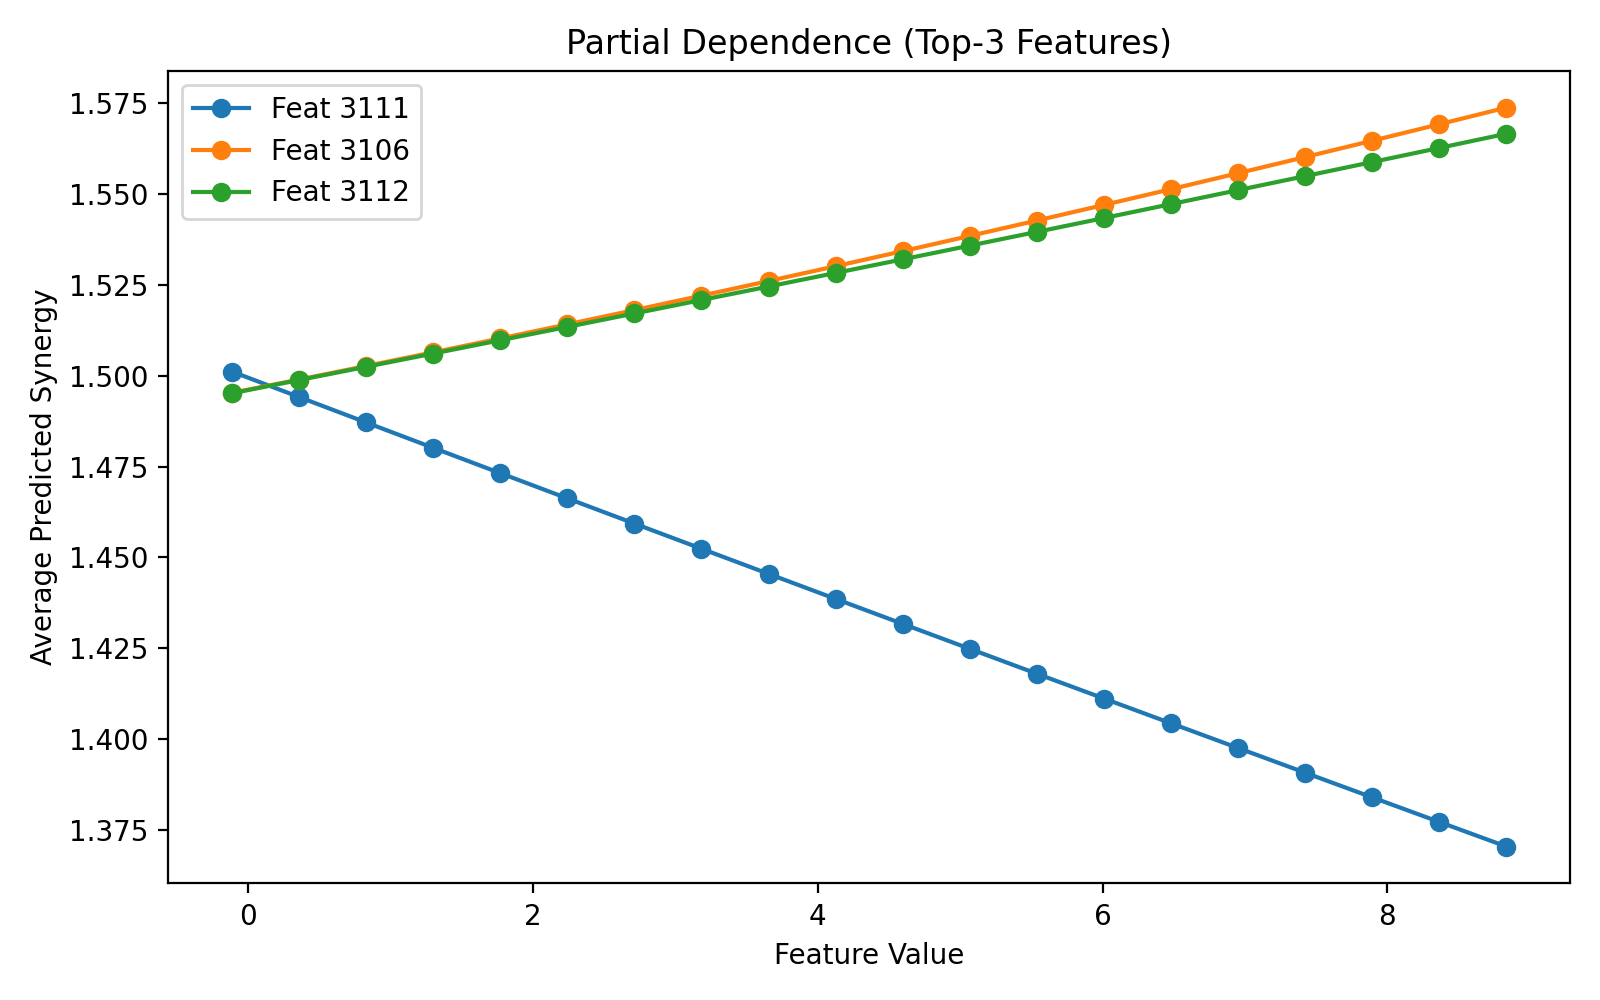

<div style="color: red; font-weight: bold;">
This method—the Partial Dependence Plot—shows the top three features that have the greatest influence on the model’s output. It’s just something what I wanted to try out and doesn't make much sense...
</div>

**Explaination:**

- If the curve goes up: higher feature values ⇒ higher model output.

- If it goes down: higher feature values ⇒ lower model output.

- If it’s flat: changing that feature has little effect on predictions.

=> **sensitivity to specific features**